In [1]:
import math
import os
import pickle
import re
import sys

import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['text.usetex'] = False
import numpy as np
import pandas as pd
from tqdm import tqdm

sys.path.insert(0, '..')
from plot_config import MODEL_COLORS, MODEL_DISPLAY_NAMES, MODEL_MARKERS, FONT_SIZES

plt.rcParams.update(FONT_SIZES)

In [4]:
project_root = "../../../.."

# Toggle: set True to load pre-computed results from disk (fast), False to run full data processing
LOAD_PROCESSED_DATA = True

PLATFORMS = {
    "HiSeq2500_150bp": "HiSeq2500_150bp",
    "NextSeq500_150bp": "NextSeq500_150bp",
    "MiSeq_v3_300bp": "MiSeq_v3_300bp",
}
platform_names = list(PLATFORMS.keys())

platform_display_names = {
    "HiSeq2500_150bp": "HiSeq2500 (150bp)",
    "NextSeq500_150bp": "NextSeq500 (150bp)",
    "MiSeq_v3_300bp": "MiSeq v3 (300bp)",
}

# Read length per platform (used for codon-level evaluation)
PLATFORM_READ_LENGTHS = {
    p: int(re.search(r"(\d+)bp", p).group(1)) for p in PLATFORMS
}

model_names = ["fgs_complete", "fgs_illumina_5", "fgs_illumina_10", "prodigal",
               "deep_cds_no_errors", "deep_cds_substitution", "deep_cds_errors"]

all_test_accessions = open(f"{project_root}/data/processed_data/genome_partitions/test_partition_accessions.txt").read().splitlines()

# Load genome info from CSV and create dict for all test accessions
genome_info_df = pd.read_csv(f"{project_root}/data/processed_data/dataset_information/genomes_info_with_partitions.csv")
genome_info_df = genome_info_df.set_index('accession')

# Families that use translation table 4 (Mycoplasmataceae and related)
tt4_families = ['Mycoplasmataceae']

all_genomes = {}
for acc in all_test_accessions:
    if acc in genome_info_df.index:
        row = genome_info_df.loc[acc]
        translation_table = 4 if row['family'] in tt4_families else 11
        all_genomes[acc] = {
            'family': row['family'],
            'domain': row['domain'],
            'gc_content': row['gc_content'],
            'translation_table': translation_table
        }

print(f"Total test accessions: {len(all_test_accessions)}")
print(f"Quality profiles with art_modern: {platform_names}")
print(f"Platform read lengths: {PLATFORM_READ_LENGTHS}")

_script_name = "cds_level_sequencer_platforms"
_cache_dir = f"{project_root}/data/processed_data/report_results/with_errors/{_script_name}"

Total test accessions: 215
Quality profiles with art_modern: ['HiSeq2500_150bp', 'NextSeq500_150bp', 'MiSeq_v3_300bp']
Platform read lengths: {'HiSeq2500_150bp': 150, 'NextSeq500_150bp': 150, 'MiSeq_v3_300bp': 300}


In [5]:
def get_full_cds(reads_dict):
    """Merge fragmented CDS annotations that belong to the same gene.

    Stores original per-fragment coords as a 4th element so that codon-level
    evaluation can assign each sub-span its correct reading frame.
    """
    for read in reads_dict.keys():
        cds_fragments_connections = reads_dict[read]['cds_fragments_connection']
        cds_coords = reads_dict[read]['cds_coords']

        indices_to_remove = []
        
        for cds_frag_mapping in cds_fragments_connections:
            if len(cds_frag_mapping) > 1:
                if len(cds_fragments_connections) != cds_frag_mapping[0] + 1:
                    if len(cds_frag_mapping) == 1:
                        cds_frag_mapping = [cds_index - 1 for cds_index in cds_frag_mapping]
                
                elif len(cds_fragments_connections) == 1 and cds_frag_mapping == [0, 2]:
                    cds_frag_mapping = [0, 1]
                elif len(cds_fragments_connections) == 1 and cds_frag_mapping == [2, 3, 4]:
                    cds_frag_mapping = [0, 1, 2]

                original_fragments = [list(cds_coords[i]) for i in sorted(cds_frag_mapping)]
                start_cds_frag = cds_coords[min(cds_frag_mapping)][0]
                end_cds_frag = cds_coords[max(cds_frag_mapping)][1]

                indices_to_remove += cds_frag_mapping
                
                assert start_cds_frag < end_cds_frag, "Something went wrong processing indel-induced error in sequence!"
                cds_coords.append([start_cds_frag, end_cds_frag, 'disrupted_rf', original_fragments])
                reads_dict[read]['cds_coords'] = cds_coords

        for index in sorted(indices_to_remove, reverse=True):
            cds_coords.pop(index)
    
    return reads_dict


# ── CDS-level helpers ─────────────────────────────────────────────────────────

def calculate_iou(coord1, coord2):
    start1, stop1, rf1 = coord1[0], coord1[1], coord1[2]
    start2, stop2, rf2 = coord2[0], coord2[1], coord2[2]
    
    if rf1 != rf2:
        return 0.0
    
    intersection_start = max(start1, start2)
    intersection_stop = min(stop1, stop2)
    
    if intersection_start >= intersection_stop:
        return 0.0
    
    intersection_length = intersection_stop - intersection_start
    union_length = max(stop1, stop2) - min(start1, start2)
    
    return intersection_length / union_length if union_length > 0 else 0.0


def find_matching_genes(predicted_coords, actual_coords):
    matched_pairs = []
    used_actual = set()
    used_predicted = set()
    
    for pred_idx, pred_coord in enumerate(predicted_coords):
        best_iou = 0.0
        best_actual_idx = -1
        
        for actual_idx, actual_coord in enumerate(actual_coords):
            if actual_idx in used_actual:
                continue
            iou = calculate_iou(pred_coord, actual_coord)
            if iou == 1.0 and iou > best_iou:
                best_iou = iou
                best_actual_idx = actual_idx
        
        if best_actual_idx != -1:
            matched_pairs.append((pred_idx, best_actual_idx))
            used_actual.add(best_actual_idx)
            used_predicted.add(pred_idx)
    
    return matched_pairs, len(matched_pairs)


def calculate_metrics(testset_dict, model_preds_dict, all_test_read_names):
    total_tp = 0
    total_predicted_genes = 0
    total_actual_genes = 0
    
    for read_name in all_test_read_names:
        cds_coords_testset = testset_dict[read_name].get("cds_coords", []) if read_name in testset_dict else []
        cds_coords_model   = model_preds_dict[read_name].get("cds_coords", []) if read_name in model_preds_dict else []
        
        _, tp_count = find_matching_genes(cds_coords_model, cds_coords_testset)

        total_predicted_genes += len(cds_coords_model)
        total_actual_genes    += len(cds_coords_testset)
        total_tp              += tp_count
    
    total_fp = total_predicted_genes - total_tp
    total_fn = total_actual_genes    - total_tp
    
    precision = total_tp / total_predicted_genes if total_predicted_genes > 0 else 0.0
    recall    = total_tp / total_actual_genes    if total_actual_genes    > 0 else 0.0
    f1_score  = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    
    return {
        'total_predicted_genes': total_predicted_genes,
        'total_actual_genes': total_actual_genes,
        'total_true_positives': total_tp,
        'total_false_positives': total_fp,
        'total_false_negatives': total_fn,
        'precision': round(precision, 3),
        'recall': round(recall, 3),
        'f1_score': round(f1_score, 3)
    }


# ── Codon-level helpers ───────────────────────────────────────────────────────

def split_by_rf(cds_coords):
    """Split CDS coordinate list into per-RF tuples, normalised to frame 0."""
    rf0, rf1, rf2 = [], [], []
    for c in cds_coords:
        if c[2] == 'disrupted_rf':
            for frag in c[3]:
                s, e, rf = frag[0], frag[1], frag[2]
                if rf == '0':   rf0.append((s, e))
                elif rf == '1': rf1.append((s - 1, e - 1))
                elif rf == '2': rf2.append((s - 2, e - 2))
        elif c[2] == '0': rf0.append((c[0], c[1]))
        elif c[2] == '1': rf1.append((c[0] - 1, c[1] - 1))
        elif c[2] == '2': rf2.append((c[0] - 2, c[1] - 2))
    return rf0, rf1, rf2


def calculate_rates_for_rf(cds_rf_testset, cds_rf_preds, codons_per_rf, seq_len):
    """Compute codon-level TP/FP/FN/TN for a single reading frame."""
    seq_len_pred = codons_per_rf * 3
    pred_covered   = np.zeros(seq_len_pred, dtype=bool)
    actual_covered = np.zeros(seq_len_pred, dtype=bool)

    for start, end in cds_rf_preds:
        pred_covered[start - 1:end] = True
    for start, end in cds_rf_testset:
        actual_covered[start - 1:end] = True

    TP = int(np.sum( pred_covered &  actual_covered) / 3)
    FP = int(np.sum( pred_covered & ~actual_covered) / 3)
    FN = int(np.sum(~pred_covered &  actual_covered) / 3)
    TN = int(np.sum(~pred_covered & ~actual_covered) / 3)

    assert TP + FP + FN + TN == codons_per_rf
    return TP, FP, FN, TN


def _mcc(TP, FP, FN, TN):
    numerator   = (TP * TN) - (FP * FN)
    denominator = math.sqrt((TP + FP) * (TP + FN) * (TN + FP) * (TN + FN))
    return numerator / denominator if denominator != 0 else 0.0


def calculate_performance_metrics_model(testset_dict, model_preds_dict, read_names_list,
                                        codons_per_rf, codons_total, seq_len):
    """Codon-level evaluation across all reads for a single model."""
    TP = FP = FN = TN = 0

    for read in read_names_list:
        in_test = read in testset_dict
        in_pred = read in model_preds_dict

        if not in_test and not in_pred:
            TN += codons_total
        elif in_test and not in_pred:
            for rf in split_by_rf(testset_dict[read]['cds_coords']):
                tp_, fp_, fn_, tn_ = calculate_rates_for_rf(rf, [], codons_per_rf, seq_len)
                TP += tp_; FP += fp_; FN += fn_; TN += tn_
        elif not in_test and in_pred:
            for rf in split_by_rf(model_preds_dict[read]['cds_coords']):
                tp_, fp_, fn_, tn_ = calculate_rates_for_rf([], rf, codons_per_rf, seq_len)
                TP += tp_; FP += fp_; FN += fn_; TN += tn_
        else:
            for rf_t, rf_p in zip(split_by_rf(testset_dict[read]['cds_coords']),
                                  split_by_rf(model_preds_dict[read]['cds_coords'])):
                tp_, fp_, fn_, tn_ = calculate_rates_for_rf(rf_t, rf_p, codons_per_rf, seq_len)
                TP += tp_; FP += fp_; FN += fn_; TN += tn_

    mcc       = _mcc(TP, FP, FN, TN)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall    = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    return {
        'tp': TP, 'fp': FP, 'fn': FN, 'tn': TN,
        'mcc': round(mcc, 4), 'f1_score': round(f1, 4),
        'precision': round(precision, 4), 'recall': round(recall, 4),
    }

In [6]:
def load_testset(test_accession, testset_name, project_root=project_root):
    """Load ground-truth testset dict and read names for a genome accession.

    Args:
        test_accession: Genome accession ID (e.g. 'GCF_000011125.1').
        testset_name: Testset directory name (e.g. 'without_errors_150bp').
        project_root: Path to project root directory.

    Returns:
        Tuple of (read_names_list, testset_dict) where testset_dict has
        fragmented CDS merged via get_full_cds().
    """
    with open(f"{project_root}/data/processed_data/testset_processed/{testset_name}/{test_accession}/testset_dict.pkl", "rb") as f:
        testset_dict = pickle.load(f)
    with open(f"{project_root}/data/processed_data/testset_processed/{testset_name}/{test_accession}/read_names_list.pkl", "rb") as f:
        read_names_list = pickle.load(f)
    return read_names_list, get_full_cds(testset_dict)


def load_model_preds(test_accession, platform, model_name, project_root=project_root):
    """Load CDS predictions for a single model and sequencer platform.

    Args:
        test_accession: Genome accession ID (e.g. 'GCF_000011125.1').
        platform: Platform name (e.g. 'HiSeq2500_150bp').
        model_name: One of 'prodigal', 'fgs_complete', 'fgs_illumina_5',
                    'deep_cds_no_errors', 'deep_cds_substitution', 'deep_cds_errors'.
        project_root: Path to project root directory.

    Returns:
        Predictions dict with fragmented CDS merged via get_full_cds().
    """
    _preds = "model_preds_dict.pkl"
    pred_paths = {
        "fgs_complete": f"{project_root}/data/processed_data/predictions/processed_predictions/fgs_preds/{platform}_complete/{test_accession}.pkl",
        "fgs_illumina_5": f"{project_root}/data/processed_data/predictions/processed_predictions/fgs_preds/{platform}_illumina_5/{test_accession}.pkl",
        "fgs_illumina_10": f"{project_root}/data/processed_data/predictions/processed_predictions/fgs_preds/{platform}_illumina_10/{test_accession}.pkl",
        "prodigal": f"{project_root}/data/processed_data/predictions/processed_predictions/prodigal_preds/{platform}/{test_accession}/{_preds}",
        "deep_cds_no_errors": f"{project_root}/data/processed_data/predictions/processed_predictions/DeepCDS/model_without_errors/{platform}/full_model_all_genomes_seed_42_trained_final_8M_no_dropout/{test_accession}/{_preds}",
        "deep_cds_substitution": f"{project_root}/data/processed_data/predictions/processed_predictions/DeepCDS/model_with_substitution_errors/{platform}/full_model_all_genomes_seed_42_trained_final_8M_no_dropout/{test_accession}/{_preds}",
        "deep_cds_errors": f"{project_root}/data/processed_data/predictions/processed_predictions/DeepCDS/model_with_errors/{platform}/full_model_all_genomes_seed_42_trained_final_8M_no_dropout/{test_accession}/{_preds}",
    }
    with open(pred_paths[model_name], "rb") as f:
        preds = pickle.load(f)
    return get_full_cds(preds)

# Evaluate performance across sequencer platforms

In [9]:
if not LOAD_PROCESSED_DATA:
    results_by_platform = {
        platform: {model: {'tp': 0, 'fp': 0, 'fn': 0} for model in model_names}
        for platform in platform_names
    }
    has_data = {platform: {model: False for model in model_names} for platform in platform_names}
    per_genome_metrics_list = {
        platform: {model: {'f1_score': [], 'precision': [], 'recall': []}
                   for model in model_names}
        for platform in platform_names
    }
    per_genome_codon_metrics_list = {
        platform: {model: {'mcc': [], 'f1_score': [], 'precision': [], 'recall': []}
                   for model in model_names}
        for platform in platform_names
    }

    for platform in platform_names:
        testset_name = PLATFORMS[platform]
        seq_len = PLATFORM_READ_LENGTHS[platform]
        codons_per_rf = (seq_len - 3) // 3
        codons_total  = codons_per_rf * 3
        print(f"\nProcessing {platform} (testset: {testset_name}, seq_len={seq_len})...")

        for test_accession in tqdm(all_test_accessions, desc=platform):
            try:
                read_names_list, testset_dict = load_testset(test_accession, testset_name)
            except Exception:
                continue

            tt = all_genomes.get(test_accession, {}).get('translation_table', None)

            for model in model_names:
                try:
                    preds = load_model_preds(test_accession, platform, model)

                    # CDS-level metrics
                    metrics = calculate_metrics(testset_dict, preds, read_names_list)
                    tp = metrics['total_true_positives']
                    fp = metrics['total_false_positives']
                    fn = metrics['total_false_negatives']

                    # Codon-level metrics
                    codon_metrics = calculate_performance_metrics_model(
                        testset_dict, preds, read_names_list, codons_per_rf, codons_total, seq_len
                    )

                    if tt != 4:
                        results_by_platform[platform][model]['tp'] += tp
                        results_by_platform[platform][model]['fp'] += fp
                        results_by_platform[platform][model]['fn'] += fn
                        has_data[platform][model] = True

                        per_genome_metrics_list[platform][model]['f1_score'].append(metrics['f1_score'])
                        per_genome_metrics_list[platform][model]['precision'].append(metrics['precision'])
                        per_genome_metrics_list[platform][model]['recall'].append(metrics['recall'])

                        for k in ['mcc', 'f1_score', 'precision', 'recall']:
                            per_genome_codon_metrics_list[platform][model][k].append(codon_metrics[k])

                except Exception:
                    continue

else:
    print(f"Loading pre-computed results from:\n  {_cache_dir}")
    with open(os.path.join(_cache_dir, "results_by_platform.pkl"), "rb") as f:
        results_by_platform = pickle.load(f)
    with open(os.path.join(_cache_dir, "has_data.pkl"), "rb") as f:
        has_data = pickle.load(f)
    with open(os.path.join(_cache_dir, "per_genome_metrics_list.pkl"), "rb") as f:
        per_genome_metrics_list = pickle.load(f)
    with open(os.path.join(_cache_dir, "per_genome_codon_metrics_list.pkl"), "rb") as f:
        per_genome_codon_metrics_list = pickle.load(f)

Loading pre-computed results from:
  ../../../../data/processed_data/report_results/with_errors/cds_level_sequencer_platforms


In [10]:
if not LOAD_PROCESSED_DATA:
    os.makedirs(_cache_dir, exist_ok=True)
    _objects_to_save = {
        "results_by_platform": results_by_platform,
        "has_data": has_data,
        "per_genome_metrics_list": per_genome_metrics_list,
        "per_genome_codon_metrics_list": per_genome_codon_metrics_list,
    }
    for _name, _obj in _objects_to_save.items():
        with open(os.path.join(_cache_dir, f"{_name}.pkl"), "wb") as f:
            pickle.dump(_obj, f)
    print(f"Results saved to {_cache_dir}")

In [12]:
# Compute aggregated metrics from raw counts
aggregated_metrics = {model: {'f1_score': [], 'precision': [], 'recall': []} for model in model_names}

for platform in platform_names:
    for model in model_names:
        if not has_data[platform][model]:
            aggregated_metrics[model]['f1_score'].append(np.nan)
            aggregated_metrics[model]['precision'].append(np.nan)
            aggregated_metrics[model]['recall'].append(np.nan)
            continue

        tp = results_by_platform[platform][model]['tp']
        fp = results_by_platform[platform][model]['fp']
        fn = results_by_platform[platform][model]['fn']

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

        aggregated_metrics[model]['f1_score'].append(f1)
        aggregated_metrics[model]['precision'].append(precision)
        aggregated_metrics[model]['recall'].append(recall)

# Compute per-genome min/max for error bars
per_genome_min_max = {
    model: {metric: {'min': [], 'max': []} for metric in ['f1_score', 'precision', 'recall']}
    for model in model_names
}
for platform in platform_names:
    for model in model_names:
        for metric in ['f1_score', 'precision', 'recall']:
            vals = per_genome_metrics_list[platform][model][metric]
            if vals:
                per_genome_min_max[model][metric]['min'].append(min(vals))
                per_genome_min_max[model][metric]['max'].append(max(vals))
            else:
                per_genome_min_max[model][metric]['min'].append(np.nan)
                per_genome_min_max[model][metric]['max'].append(np.nan)

# Plot performance across sequencer platforms

In [13]:
model_display_names = MODEL_DISPLAY_NAMES
model_colors = MODEL_COLORS
model_markers = MODEL_MARKERS

In [17]:
def plot_metric_by_platform_boxplot(per_genome_metrics_list, platform_names, metric_name, ylabel,
                                    filename_prefix="cds"):
    """Plot per-genome metric distributions as grouped boxplots across sequencer platforms."""
    active_models = [m for m in model_names
                     if any(per_genome_metrics_list[p][m][metric_name] for p in platform_names)]
    if not active_models:
        print("No data available.")
        return

    n_active = len(active_models)
    matplotlib.rcParams['text.usetex'] = False
    fig, ax = plt.subplots(figsize=(11, 7))

    x_positions = np.arange(len(platform_names))
    box_width = 0.8 / n_active
    offsets = (np.arange(n_active) - (n_active - 1) / 2) * box_width

    for k, model in enumerate(active_models):
        color = MODEL_COLORS[model]
        positions, data = [], []
        for i, platform in enumerate(platform_names):
            vals = per_genome_metrics_list[platform][model][metric_name]
            if vals:
                positions.append(x_positions[i] + offsets[k])
                data.append(vals)
        if not data:
            continue

        bp = ax.boxplot(
            data,
            patch_artist=True,
            positions=positions,
            widths=box_width * 0.9,
            showfliers=True,
            flierprops=dict(marker='o', markersize=3, alpha=0.5,
                            markerfacecolor=color, markeredgecolor=color),
            manage_ticks=False,
        )
        for patch in bp['boxes']:
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        for line in bp['medians']:
            line.set_color('black')
            line.set_linewidth(1.5)
        ax.plot([], [], color=color, linewidth=6, alpha=0.7,
                label=MODEL_DISPLAY_NAMES[model])

    ax.set_xlabel('Quality Profile (sequence length)', fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    ax.set_xticks(x_positions)
    ax.set_xticklabels([platform_display_names[p] for p in platform_names])
    ax.set_ylim(0.45, 1.01)
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend(bbox_to_anchor=(0.5, -0.1), loc='upper center', ncol=4)

    plt.tight_layout()
    # plt.savefig(f"{filename_prefix}_prediction_metrics_by_platform_boxplot_{metric_name}.svg", dpi=500)
    plt.show()

# CDS-level boxplots of performance

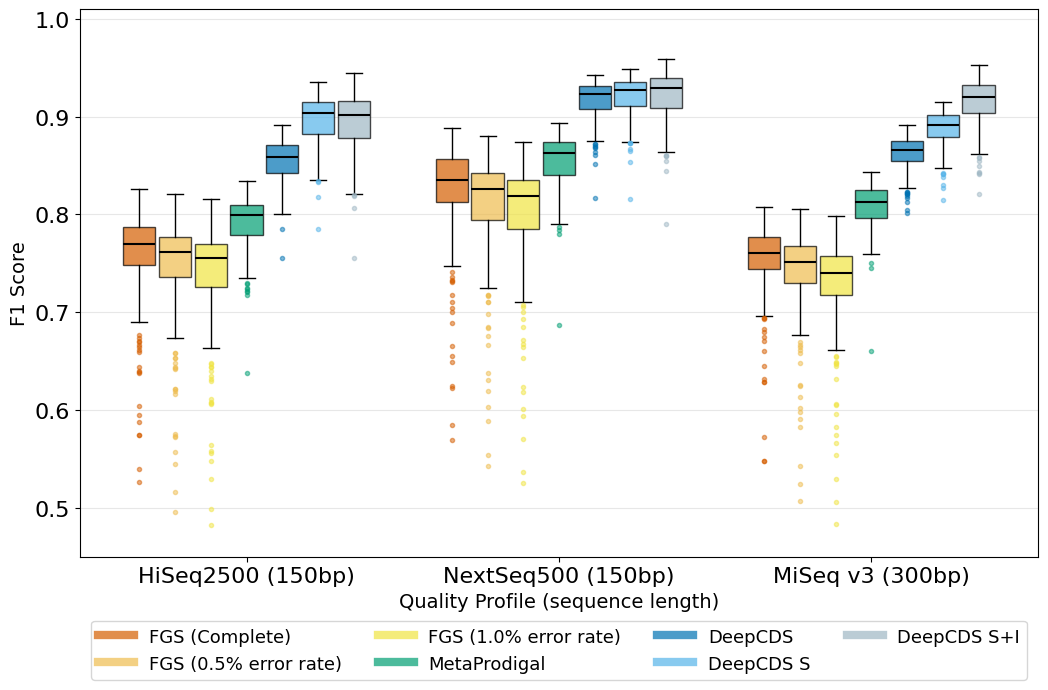

In [18]:
# CDS-level boxplots
plot_metric_by_platform_boxplot(per_genome_metrics_list, platform_names, 'f1_score', 'F1 Score',
                                filename_prefix="cds")

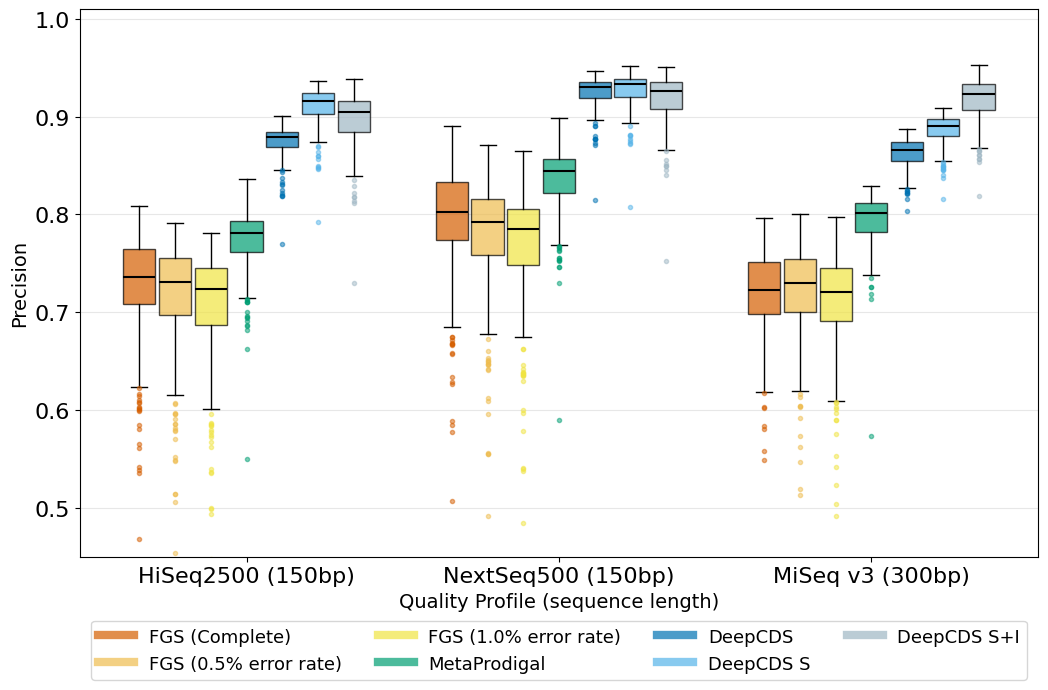

In [20]:
plot_metric_by_platform_boxplot(per_genome_metrics_list, platform_names, 'precision', 'Precision',
                                filename_prefix="cds")

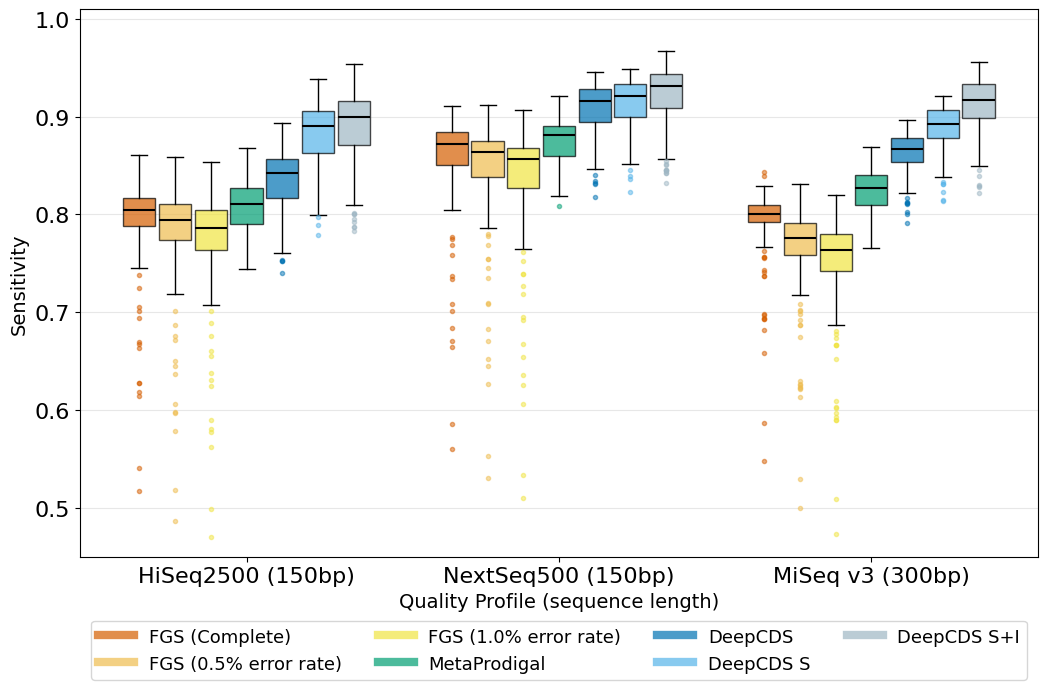

In [21]:
plot_metric_by_platform_boxplot(per_genome_metrics_list, platform_names, 'recall', 'Sensitivity',
                                filename_prefix="cds")

# Codon-level boxplots of performance

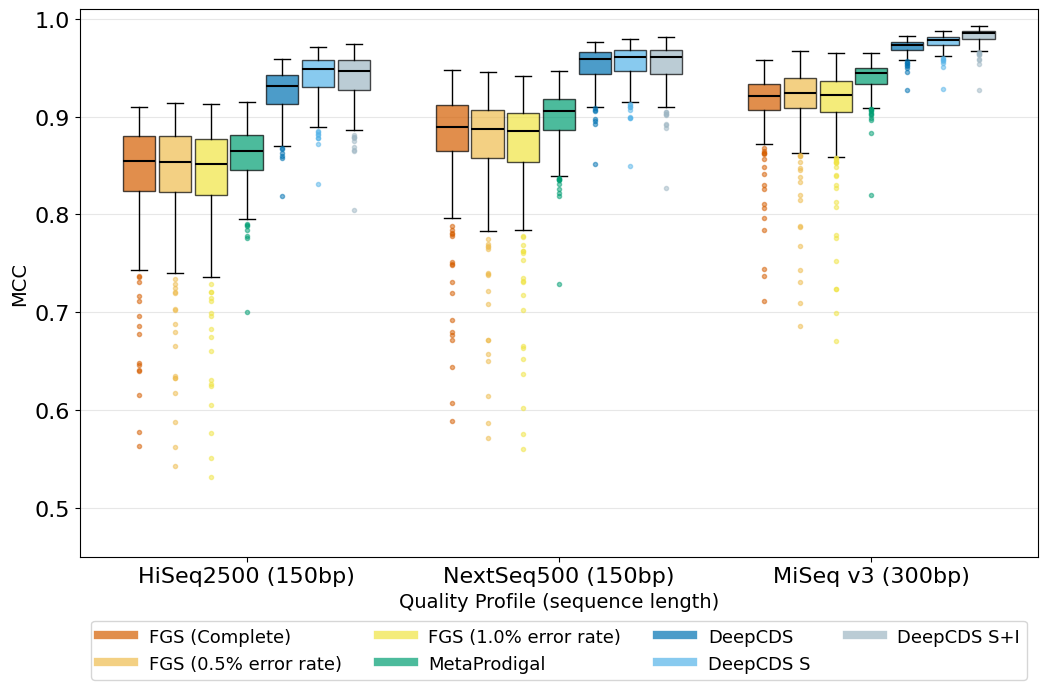

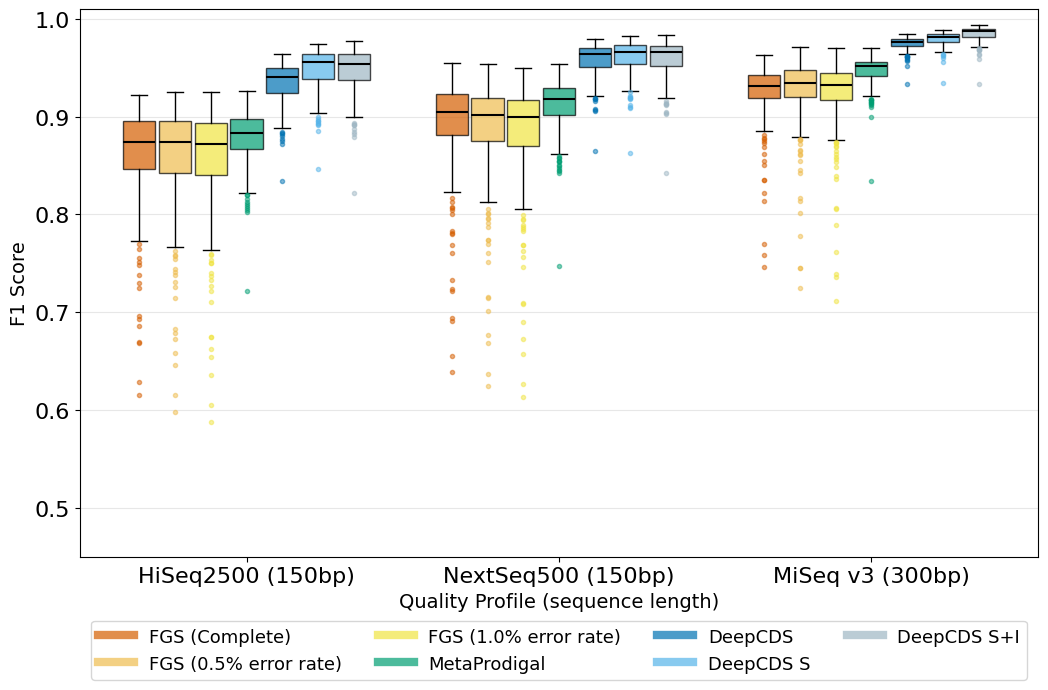

In [22]:
# Codon-level boxplots
plot_metric_by_platform_boxplot(per_genome_codon_metrics_list, platform_names, 'mcc', 'MCC',
                                filename_prefix="codon")
plot_metric_by_platform_boxplot(per_genome_codon_metrics_list, platform_names, 'f1_score', 'F1 Score',
                                filename_prefix="codon")

In [23]:
# Generate LaTeX table with 3 metric sections (F1, Sensitivity, Precision)
# Rows: model names; Columns: platforms
# Best score per platform is bolded

metrics_order = [
    ('f1_score', 'F1 Score'),
    ('recall', 'Sensitivity'),
    ('precision', 'Precision'),
]

col_fmt = 'l' + 'c' * len(platform_names)
header_cols = ' & '.join([platform_display_names[p] for p in platform_names])

lines = []
lines.append(r'\begin{table}[ht]')
lines.append(r'\centering')
lines.append(rf'\begin{{tabular}}{{{col_fmt}}}')
lines.append(r'\toprule')
lines.append(f' & {header_cols} \\\\')

for sec_idx, (metric_key, metric_label) in enumerate(metrics_order):
    lines.append(r'\midrule')
    lines.append(rf'\multicolumn{{{1 + len(platform_names)}}}{{l}}{{\textbf{{{metric_label}}}}} \\')
    lines.append(r'\midrule')

    # Find best value per platform for this metric
    best_per_platform = []
    for i in range(len(platform_names)):
        col_vals = [aggregated_metrics[model][metric_key][i] for model in model_names]
        valid = [v for v in col_vals if not np.isnan(v)]
        best_per_platform.append(max(valid) if valid else None)

    for model in model_names:
        display = model_display_names[model]
        vals = []
        for i, platform in enumerate(platform_names):
            v = aggregated_metrics[model][metric_key][i]
            if np.isnan(v):
                vals.append('--')
            elif best_per_platform[i] is not None and v == best_per_platform[i]:
                vals.append(rf'\textbf{{{v:.3f}}}')
            else:
                vals.append(f'{v:.3f}')
        row = f'{display} & ' + ' & '.join(vals) + r' \\'
        lines.append(row)

lines.append(r'\bottomrule')
lines.append(r'\end{tabular}')
lines.append(r'\caption{TODO: WRITE CAPTION. Aggregated performance across genomes}')
lines.append(r'\label{tab:cds_sequencer_platforms}')
lines.append(r'\end{table}')

latex_table = '\n'.join(lines)
print(latex_table)

\begin{table}[ht]
\centering
\begin{tabular}{lccc}
\toprule
 & HiSeq2500 (150bp) & NextSeq500 (150bp) & MiSeq v3 (300bp) \\
\midrule
\multicolumn{4}{l}{\textbf{F1 Score}} \\
\midrule
FGS (Complete) & 0.767 & 0.831 & 0.758 \\
FGS (0.5% error rate) & 0.756 & 0.818 & 0.746 \\
FGS (1.0% error rate) & 0.748 & 0.810 & 0.734 \\
MetaProdigal & 0.794 & 0.857 & 0.813 \\
DeepCDS & 0.860 & 0.920 & 0.867 \\
DeepCDS S & \textbf{0.900} & 0.924 & 0.892 \\
DeepCDS S+I & 0.899 & \textbf{0.925} & \textbf{0.920} \\
\midrule
\multicolumn{4}{l}{\textbf{Sensitivity}} \\
\midrule
FGS (Complete) & 0.804 & 0.867 & 0.799 \\
FGS (0.5% error rate) & 0.793 & 0.856 & 0.771 \\
FGS (1.0% error rate) & 0.785 & 0.847 & 0.757 \\
MetaProdigal & 0.813 & 0.877 & 0.828 \\
DeepCDS & 0.843 & 0.913 & 0.868 \\
DeepCDS S & 0.887 & 0.917 & 0.894 \\
DeepCDS S+I & \textbf{0.896} & \textbf{0.928} & \textbf{0.918} \\
\midrule
\multicolumn{4}{l}{\textbf{Precision}} \\
\midrule
FGS (Complete) & 0.732 & 0.797 & 0.721 \\
FGS (0.5% error r